# From text to tensors: tokenization & embeddings

Every model we've built so far has taken floats in and produced floats out. Real-world AI mostly works with **text** — sentences, code, books, prompts. Before any of our PyTorch machinery can touch a string, the string has to become numbers.

That conversion has two stages, and each is a small subject in its own right:

1. **Tokenization** — chop text into discrete pieces ("tokens") and assign each one an integer id. This is what `data/shakespeare_char/prepare.py` does for nanoGPT, and what `tiktoken` does for GPT models.
2. **Embedding** — turn those integer ids into dense, learned vectors that the network can manipulate with linear algebra. `nn.Embedding` is just a lookup table of learnable weights.

### The tour

- 🔤 **Three tokenization strategies**, demoed live: character, word, and subword (BPE).
- 🌍 **Real-world tokenizers** — `tiktoken` comparisons across GPT-2, GPT-4, GPT-4o, and the cross-language fairness problem.
- 🪦 **Glitch tokens** — vocab entries the language model never actually trained on.
- 🎯 **Embeddings** — how integer ids become meaningful vectors via plain gradient descent.

By the end, you'll have everything notebook 7 needs to feed the same Shakespeare corpus into an RNN.

In [ ]:
%load_ext autoreload
%autoreload 2

import os
import io
import urllib.request
from collections import Counter
from html import escape

import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
import torch
import torch.nn as nn
from IPython.display import HTML, display

pio.renderers.default = "notebook"

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
print(f"PyTorch: {torch.__version__}")
print(f"Device:  {device}")

## The gap

PyTorch tensors are grids of floats. A string is… not.

```python
>>> torch.tensor("Hello, world")
TypeError: must be real number, not str
```

Before we can train anything on text we need a **deterministic, reversible function** that maps strings to sequences of integers and back:

$$\text{encode}: \text{str} \to [\text{int}, \text{int}, \ldots] \qquad \text{decode}: [\text{int}, \text{int}, \ldots] \to \text{str}$$

That function is called a **tokenizer**. There are roughly three families of strategies. Let's build them from simplest to most clever, on the same text.

## Strategy 1 — character-level

The dumbest thing that works: treat **each character** as a token. Build a vocab of every distinct character in your corpus and assign each an integer.

Pros: tiny vocab, zero out-of-vocabulary problem (any unseen character… well, becomes an out-of-vocab problem, but if you train on a large enough corpus you see every letter). Cons: sequences are long, the model has to learn spelling *and* grammar simultaneously.

Demo on Karpathy's Tiny Shakespeare (~1.1 MB of plays):

In [ ]:
# Download Tiny Shakespeare (one-time)
data_path = "data/shakespeare_char/input.txt"
if not os.path.exists(data_path):
    os.makedirs(os.path.dirname(data_path), exist_ok=True)
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    print(f"Downloading {url} ...")
    urllib.request.urlretrieve(url, data_path)

with open(data_path, "r") as f:
    text = f.read()

# Build the character vocab
chars = sorted(set(text))
vocab_size_char = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

def char_encode(s):  return [stoi[c] for c in s]
def char_decode(xs): return "".join(itos[int(i)] for i in xs)

print(f"Corpus length:  {len(text):,} characters")
print(f"Vocab size:     {vocab_size_char}")
print(f"Vocab:          {''.join(chars)!r}")
print()

# Demo on a short string
sample = "Hello, world!"
ids = char_encode(sample)
print(f"encode({sample!r})")
print(f"   = {ids}")
print(f"decode(...)")
print(f"   = {char_decode(ids)!r}")
print()
print(f"=> 13 characters become {len(ids)} integer ids. Reversible.")

## Strategy 2 — word-level

The next obvious idea: treat **each word** as a token. Split on whitespace, assign each unique word an integer.

Pros: tokens now carry semantic meaning ("hello" is one thing, not five letters). Sequences become much shorter. Cons: the vocab explodes (every plural, every typo, every proper noun is its own entry), and any word the tokenizer never saw before becomes `<UNK>` — the model is blind to it.

In [ ]:
# Build a word-level vocab by simply splitting on whitespace.
words = text.split()
word_counts = Counter(words)
word_vocab = sorted(word_counts.keys())
word_stoi = {w: i for i, w in enumerate(word_vocab)}
word_itos = {i: w for i, w in enumerate(word_vocab)}

print(f"Corpus:            {len(words):,} word tokens")
print(f"Word vocab size:   {len(word_vocab):,}    ← compare with {vocab_size_char} for char-level")
print(f"Most common:       {word_counts.most_common(5)}")
print()

# Compress factor: how many *integers* do we need now vs. char-level?
print(f"Char-level needs   {len(text):>9,} integers")
print(f"Word-level needs   {len(words):>9,} integers   "
      f"(≈ {len(text) / len(words):.1f}× fewer)")
print()

# The OOV problem: any word the corpus never saw can't be tokenized.
def word_encode(s):
    return [word_stoi.get(w, None) for w in s.split()]

new_sentence = "Shakespeare wrote tokenizers? Quantum cryptography rocks!"
encoded = word_encode(new_sentence)
print(f"Try a sentence with words Shakespeare never wrote:")
print(f"   {new_sentence!r}")
print(f"   -> {encoded}")
missing = [w for w in new_sentence.split() if w not in word_stoi]
print(f"   {len(missing)} words map to None (out-of-vocab): {missing}")
print()
print("This is why classical NLP needed an <UNK> token, and why the model went blind")
print("on anything novel. The next strategy fixes this for good.")

## Strategy 3 — subword (BPE)

The modern compromise: learn a vocab of **frequent character chunks** from data. Common words like `"the"` get one token. Rare or novel words like `"Tokenization"` decompose into pieces (`"Token"` + `"ization"`) the model has seen elsewhere. Anything truly novel falls back to byte-level tokens — **no `<UNK>`, ever.**

This is what every modern LLM uses. OpenAI ships their tokenizer as `tiktoken`, and it's already a dependency of this repo (nanoGPT uses it). Let's use it to see how three real GPT tokenizers segment the **same** English sentence.

In [ ]:
import tiktoken

# Palette for color-coded token chips (cycles)
_PALETTE = [
    "#fbb4ae", "#b3cde3", "#ccebc5", "#decbe4", "#fed9a6",
    "#ffffcc", "#e5d8bd", "#fddaec", "#f2f2f2", "#a6cee3",
]

def render_tokens_html(ids, pieces, palette=_PALETTE):
    """Render parallel id+text lists as inline color-coded HTML chips."""
    chips = []
    for i, (tid, piece) in enumerate(zip(ids, pieces)):
        color = palette[i % len(palette)]
        # Make whitespace visible: spaces -> · , newlines -> ⏎ + line break
        shown = escape(piece).replace(" ", "·").replace("\n", "⏎<br>")
        chips.append(
            f'<span style="background:{color};padding:2px 5px;margin:1px;'
            f'border-radius:3px;font-family:monospace;font-size:0.95em;" '
            f'title="id={tid}">{shown}</span>'
        )
    return "".join(chips)


def tokenize_block(text, encoding_name, label=None):
    """Return an HTML block: 'label (vocab=V, N tokens):  <chips>'."""
    enc = tiktoken.get_encoding(encoding_name)
    ids = enc.encode(text)
    # Decode each id individually so we get the literal piece per token
    pieces = [enc.decode([tid]) for tid in ids]
    label = label or encoding_name
    return (
        f"<div style='margin-bottom:14px;'>"
        f"<b>{label}</b> &nbsp;<span style='color:#666'>"
        f"(vocab={enc.n_vocab:,}, <b>{len(ids)} tokens</b>)</span><br>"
        f"{render_tokens_html(ids, pieces)}</div>"
    )


SAMPLE = "Hello, world! Tokenization is genuinely fascinating, isn't it?"

# Three tokenizers, one sentence
encodings = [
    ("gpt2",         "GPT-2 / GPT-3"),
    ("cl100k_base",  "GPT-3.5 / GPT-4"),
    ("o200k_base",   "GPT-4o"),
]
blocks = []
for name, label in encodings:
    try:
        blocks.append(tokenize_block(SAMPLE, name, label=label))
    except Exception as e:
        blocks.append(
            f"<div style='color:#a33'>{label}: not available "
            f"({type(e).__name__}: {e})</div>"
        )

display(HTML(
    f"<div style='line-height:1.9;font-size:14px;'>"
    f"<b>Input:</b>  <code>{escape(SAMPLE)}</code><br><br>"
    + "".join(blocks) +
    "</div>"
))

### The fairness problem

Tokenizers are trained on a corpus. If the training corpus is mostly English (and early ones were), then English text gets compressed well — common words become single tokens — while text in other languages gets broken into much smaller pieces.

**Same sentence, three languages, two tokenizers:**

In [ ]:
# Same meaning, six different inputs. (Translations are intentionally short.)
SENTENCES = {
    "English":  "The weather is beautiful today.",
    "German":   "Das Wetter ist heute wunderschön.",
    "Chinese":  "今天天气很美。",
    "Hindi":    "आज मौसम बहुत सुंदर है।",
    "Arabic":   "الطقس جميل اليوم.",
    "Burmese":  "ဒီနေ့မိုးလေဝသကောင်းတယ်။",
}

# Table of (language, gpt2 tokens, o200k_base tokens, ratio)
print(f"{'language':<10s}  {'chars':>6s}  {'gpt2':>6s}  {'o200k':>6s}  {'gpt2/o200k':>10s}")
print("-" * 50)
enc_gpt2  = tiktoken.get_encoding("gpt2")
enc_o200k = tiktoken.get_encoding("o200k_base")
for lang, sent in SENTENCES.items():
    n_chars = len(sent)
    n_gpt2  = len(enc_gpt2.encode(sent))
    n_o200k = len(enc_o200k.encode(sent))
    print(f"{lang:<10s}  {n_chars:>6d}  {n_gpt2:>6d}  {n_o200k:>6d}  {n_gpt2/n_o200k:>9.2f}x")

# Show the worst case visually
print()
print("Burmese, GPT-2 vs GPT-4o:")
display(HTML(
    "<div style='line-height:1.9'>"
    + tokenize_block(SENTENCES["Burmese"], "gpt2", "GPT-2")
    + tokenize_block(SENTENCES["Burmese"], "o200k_base", "GPT-4o")
    + "</div>"
))

### Code: indentation as tokens

Python's significant whitespace was a headache for early tokenizers. Each leading space could become its own token, ballooning the cost of code. Modern tokenizers learn merged tokens for `\n    `, `\n        `, etc., shrinking source files by 30–50%.

In [ ]:
PY_SAMPLE = (
    "def fizzbuzz(n):\n"
    "    for i in range(1, n + 1):\n"
    "        if i % 15 == 0:\n"
    "            print('FizzBuzz')\n"
    "        elif i % 3 == 0:\n"
    "            print('Fizz')\n"
    "        elif i % 5 == 0:\n"
    "            print('Buzz')\n"
    "        else:\n"
    "            print(i)"
)

print(f"Source: {len(PY_SAMPLE)} characters\n")
for name, label in [("gpt2", "GPT-2"), ("cl100k_base", "GPT-4"), ("o200k_base", "GPT-4o")]:
    enc = tiktoken.get_encoding(name)
    n = len(enc.encode(PY_SAMPLE))
    chars_per_tok = len(PY_SAMPLE) / n
    print(f"   {label:<7s} → {n:>3d} tokens  ({chars_per_tok:.2f} chars/token)")
print()
print("First few lines as colored chips (GPT-2 vs GPT-4o):")
short = "    for i in range(1, n + 1):\n        if i % 15 == 0:"
display(HTML(
    "<div style='line-height:1.9'>"
    + tokenize_block(short, "gpt2", "GPT-2")
    + tokenize_block(short, "o200k_base", "GPT-4o")
    + "</div>"
))

## What real models actually use

| Model / family | Tokenizer | Algorithm | Vocab size | ≈ chars / token (English)¹ |
| --- | --- | --- | ---: | ---: |
| This notebook (char) | hand-rolled | character | **65** | 1.0 |
| BERT (2018) | `bert-base-uncased` | WordPiece | 30,522 | ~4.0 |
| GPT-2 / GPT-3 (2019–2020) | `gpt2` | byte-level BPE | 50,257 | ~4.0 |
| Llama 2 / Mistral 7B (2023) | sentencepiece | SentencePiece BPE | 32,000 | ~3.5 |
| GPT-3.5 / GPT-4 (2023) | `cl100k_base` | byte-level BPE | 100,277 | ~4.0 |
| Llama 3 (2024) | tiktoken-style | byte-level BPE | 128,256 | ~4.3 |
| DeepSeek-V3 (2024) | sentencepiece | byte-level BPE | 129,280 | ~4.5 |
| Qwen2 / 2.5 (2024) | sentencepiece | byte-level BPE | ~151,936 | ~4.5 |
| GPT-4o (2024) | `o200k_base` | byte-level BPE | 200,019 | ~4.5–5.0 |
| Gemini / PaLM 2 (2024) | sentencepiece | SentencePiece | ~256,128 | ~5.0 |

¹ Approximate. Code, numbers, and non-English text give different ratios — as we just saw.

**Trends to notice:**

- Every modern tokenizer is **byte-level BPE** (or close). They learn merges from data and never produce `<UNK>`.
- **Vocab sizes are growing**: 30k → 50k → 100k → 200k+. Bigger vocab = fewer tokens per page of text.
- Most of the growth from `cl100k_base` to `o200k_base` is **non-English and code coverage**.

## Why the choice matters

The strategy a model team picks shows up everywhere downstream:

- **Compute & context budget.** Attention is **quadratic in sequence length**. A tokenizer that hits 4.5 chars/token instead of 3.5 sees a 1.3× shorter sequence — and ~1.7× less attention cost — for the same text.
- **Multilingual fairness.** Same string can be 5–10× more tokens in some languages, as we saw. Non-English users pay more (API cost) and lose more (effective context).
- **Numbers & arithmetic.** GPT-3 sometimes split `1234` as `123` + `4`, sometimes as `12` + `34`. Newer tokenizers deliberately tokenize digits **one at a time** so the model can reason over them uniformly. (Try `tiktoken.get_encoding("o200k_base").encode("1234567")` and look at the ids.)
- **Code.** Modern tokenizers learn merges for `\n    `, `\n        `, etc. — the difference we just saw.
- **"How many R's in 'strawberry'?"** fails because the model sees `straw` + `berry`, two opaque ids. It never sees individual letters. Same root cause: spelling, reversing, anagrams, letter counting — all tokenizer-shaped holes.
- **Embedding cost.** Every vocab token is a row in the embedding table (and another in the LM-head). For a model with hidden size $d$, the two together cost $2 \cdot \text{vocab} \cdot d$ parameters. That's why most open-weights models sit around 32k–128k rather than going bigger.

**TL;DR:** tokenization is the lossy interface between messy real-world text and clean integer ids, and every quirk of that interface shows up in model behavior.

## Aside — glitch tokens

Tokenizers are learned **separately** from the language model, on a different (often larger) corpus. Consequence: the vocab can contain entries that the LM itself barely saw during training. With nearly no gradient signal, the embedding row for such a token stays close to its random initialization — the model has no idea what it means. Feeding it in produces unhinged output: hallucinated translations, refusals, gibberish, repetition loops.

The most famous example is the GPT-2/3 token ` SolidGoldMagikarp` — a Reddit username that ended up in the BPE training corpus but not the LM corpus. Asking GPT-3 to repeat it would cause confident gibberish.

Let's verify it's actually a single token in `gpt2`:

In [ ]:
gpt2 = tiktoken.get_encoding("gpt2")

# Known glitch tokens from gpt2 / cl100k_base. (Some are well-known, some less so.)
glitchy = [
    " SolidGoldMagikarp",
    " petertodd",
    " TheNitromeFan",
    "rawdownload",
]
# Compare to a normal English phrase
normal = " hello world"

print(f"{'token':<28s}  {'gpt2 ids':>22s}  {'#':>4s}")
print("-" * 60)
for tok in glitchy + [normal]:
    ids = gpt2.encode(tok)
    print(f"{tok!r:<28s}  {str(ids):>22s}  {len(ids):>4d}")

print()
print("Each of those Reddit-derived strings collapses to a SINGLE id — meaning")
print("BPE learned that exact byte sequence as a merge. But the LM rarely saw it")
print("at train time, so the corresponding embedding row stayed near-random.")
print()
print("(Live demo of feeding one of these to a model: see the terminal next door.)")

## From integers to vectors: `nn.Embedding`

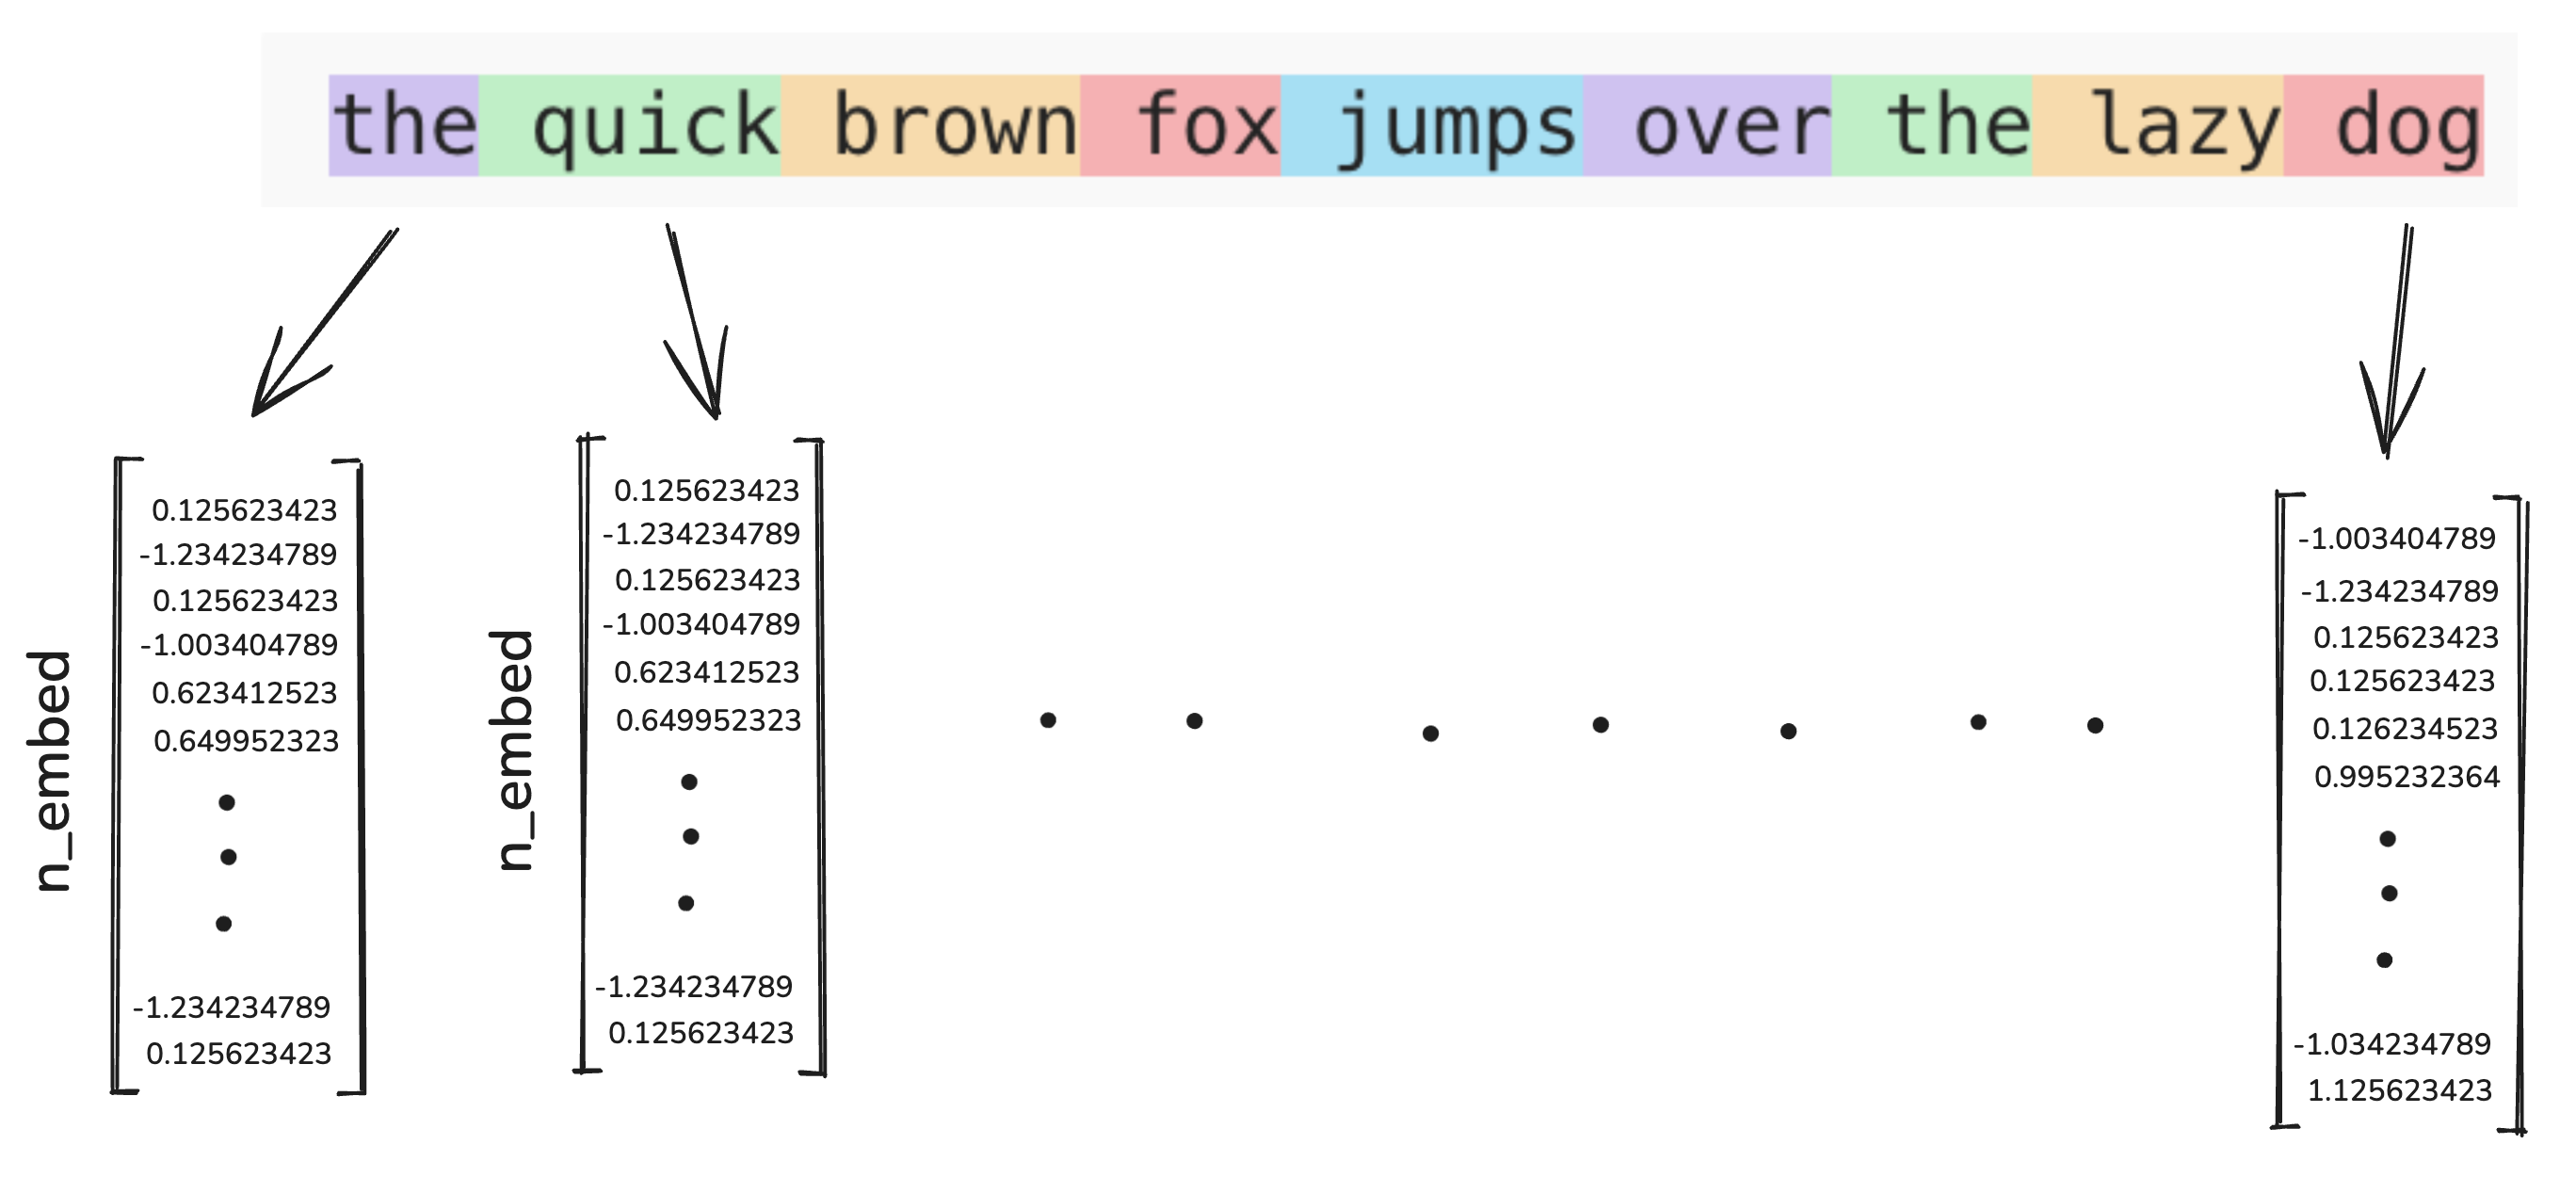

After tokenization we have integer ids. But the integer `42` is just as far from `41` as it is from `7000` — the numbers themselves carry **no useful structure**. The model needs **vectors**: small dense arrays of floats it can do linear algebra with.

The conversion mechanism is `nn.Embedding`. The transition from "I have integers" to "I have meaningful 256-dimensional vectors" feels like sleight of hand. It isn't.

### `nn.Embedding(V, H)` is just a $V \times H$ matrix

Under the hood, `nn.Embedding(65, 256)` allocates a single learnable parameter: a matrix `W` of shape `(65, 256)`. Random init. That's all it is.

When you call `embed(7)`, the layer **returns row 7** of that matrix — a vector of length 256. Looking up token 7 is the same operation as multiplying a one-hot vector $\mathbf{e}_7$ by $W$, but skipping the wasteful 64 multiplications by zero:

$$
\underbrace{[0,0,0,0,0,0,0,1,0,\ldots,0]}_{1 \times V} \cdot \underbrace{W}_{V \times H} \;=\; \text{row 7 of } W
$$

### How it learns

The embedding matrix is registered as an `nn.Parameter`, so autograd tracks gradients through it like any other weight.

1. **Forward**: row 7 of $W$ flows into the rest of the network → loss.
2. **Backward**: autograd deposits a gradient onto row 7 (and *only* row 7 — none of the other rows were touched in this forward pass).
3. **Optimizer step**: row 7 is nudged in the direction that would have reduced the loss.

After many batches each row drifts from its random init into a position that's useful for the task. "What does it mean" is whatever the optimizer found convenient.

In [ ]:
# A tiny, concrete look at what nn.Embedding actually contains.
toy = nn.Embedding(num_embeddings=5, embedding_dim=3)
print("toy.weight shape:", tuple(toy.weight.shape), "   requires_grad:", toy.weight.requires_grad)
print("\nInitial (random) weight matrix:")
print(toy.weight.data, "\n")

# Look up token id 2 — literally row 2 of the matrix
print("toy(tensor([2]))  -> row 2:")
print(toy(torch.tensor([2])).detach(), "\n")

# Equivalent matmul (slow but proves they're the same)
one_hot = torch.zeros(1, 5); one_hot[0, 2] = 1.0
print("one_hot_at_2 @ toy.weight  ->")
print((one_hot @ toy.weight).detach())

### Do trained embeddings actually learn structure?

Claim: random matrices in, **structured** matrices out. Let's check.

We train a *very* tiny next-character predictor on Shakespeare for a few seconds. The model is just:

$$\text{logits}(c) \;=\; W_\text{out}\,\cdot\,\text{embed}(c)$$

The embedding row for each character has to encode enough information about that character to predict what comes next. So characters that appear in **similar contexts** (same characters around them) should end up with **similar embeddings**.

After training, we PCA the 65×D embedding matrix down to 2-D and plot the characters. Watch for:

- vowels cluster together (same job: follow consonants, precede consonants)
- capital letters cluster together (start-of-line, start-of-name role)
- punctuation forms its own neighborhood
- whitespace and rare chars sit off on their own

In [ ]:
import torch.nn.functional as F

# ---- Tiny bigram-style char model: just embed + linear projection ----
class CharBigram(nn.Module):
    def __init__(self, vocab_size, embed_dim=24):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.out   = nn.Linear(embed_dim, vocab_size)
    def forward(self, x):
        return self.out(self.embed(x))

# ---- Train ----
data = torch.tensor(char_encode(text), dtype=torch.long, device=device)
torch.manual_seed(0)
model_emb = CharBigram(vocab_size_char, embed_dim=24).to(device)
opt = torch.optim.Adam(model_emb.parameters(), lr=3e-3)

batch_size, n_steps = 1024, 2000
for step in range(n_steps):
    ix = torch.randint(0, len(data) - 1, (batch_size,), device=device)
    loss = F.cross_entropy(model_emb(data[ix]), data[ix + 1])
    opt.zero_grad(); loss.backward(); opt.step()
print(f"Final next-char cross-entropy: {loss.item():.4f}    "
      f"(uniform-random baseline = {np.log(vocab_size_char):.4f})")

# ---- PCA the learned 65x24 embedding matrix down to 2 dims ----
emb = model_emb.embed.weight.detach().cpu().numpy()
emb_c = emb - emb.mean(0, keepdims=True)
U, S, _ = np.linalg.svd(emb_c, full_matrices=False)
emb_2d = U[:, :2] * S[:2]                     # shape (65, 2)

# ---- Color-code by character category for visual structure ----
def category(c):
    if c in "aeiouAEIOU":    return "vowel"
    if c.isalpha():           return "consonant"
    if c.isdigit():           return "digit"
    if c.isspace():           return "whitespace"
    return "punctuation"

cat_color = {
    "vowel":        "crimson",
    "consonant":    "steelblue",
    "digit":        "darkorange",
    "whitespace":   "gray",
    "punctuation":  "seagreen",
}
cats = [category(c) for c in chars]

emb_fig = go.Figure()
for cat in ["consonant", "vowel", "digit", "punctuation", "whitespace"]:
    mask = [c == cat for c in cats]
    xs = emb_2d[mask, 0]
    ys = emb_2d[mask, 1]
    labels = [chars[i] for i, m in enumerate(mask) if m]
    # Make whitespace visible
    pretty = [repr(c) if (c == "\n" or c == " ") else c for c in labels]
    emb_fig.add_trace(go.Scatter(
        x=xs, y=ys, mode="markers+text",
        marker=dict(size=14, color=cat_color[cat],
                    line=dict(color="black", width=0.8), opacity=0.8),
        text=pretty, textposition="top center",
        textfont=dict(size=14),
        name=cat, hoverinfo="text",
    ))
emb_fig.update_layout(
    title="2-D PCA of the learned character embeddings",
    xaxis_title="PC 1", yaxis_title="PC 2",
    template="plotly_white",
    width=780, height=560,
    legend=dict(orientation="h", y=-0.12),
)
emb_fig.show()

## Wrap-up

We can now do the two things every text-based neural network needs:

| | Operation | Output |
| --- | --- | --- |
| **Tokenize** | string → list of integer ids | tensor of shape `(T,)` |
| **Embed**    | integer ids → dense vectors  | tensor of shape `(T, H)` |

The first is a deterministic preprocessing function the model team commits to once and rarely changes. The second is a learnable matrix that grows structure through gradient descent.

Everything beyond this point — RNNs, LSTMs, transformers, GPTs — operates on the embedded vectors. The model **never sees characters or words directly**; it only ever sees rows of the embedding table.

➡️ Continue in **`7_rnn.ipynb`**, where we feed this same tokenized Shakespeare into a hand-rolled recurrent network and use it to generate fresh (slightly nonsensical) Shakespeare.